<a href="https://colab.research.google.com/github/SunnyLim794/QFD_ML/blob/main/FinBERTBankv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Packages and Load Data

In [ ]:
import os
import re
import pandas as pd
from pathlib import Path
!pip install pdfminer.six # Install the missing library
from pdfminer.high_level import extract_text

# Load file and check for missing values

import pandas as pd
from IPython.display import display
engine = "openpyxl"

# Mount your drive
from google.colab import drive
drive.mount('/content/gdrive')


# Correct Google Drive path
BASE_DIR = Path("/content/gdrive/My Drive/data/")
BASE_DIR.mkdir(parents=True, exist_ok=True)

BANKS = ["HSBC", "BARC"]


def extract_qa_from_text(text):
    """
    Robust Q&A extractor for HSBC + Barclays transcripts.
    Handles:
    - Question - Name
    - Answer - Name
    - Q (Name)
    - A (Name)
    - Analyst (Name)
    - Management (Name)
    - <Q> ... </Q>
    - <A> ... </A>
    """

    # Identify Q&A start using broader patterns
    qa_start = re.search(
        r"(Q&A|Question\s*-\s*|<Q>|Analyst)",
        text,
        re.IGNORECASE
    )
    if not qa_start:
        return []

    qa_text = text[qa_start.start():]

    # Split into lines
    lines = [l.strip() for l in qa_text.split("\n") if l.strip()]

    qa_pairs = []
    current_question = []
    current_answer = []
    mode = None

    for line in lines:

        # QUESTION patterns
        if re.search(r"^(Question\s*-|Q\s*\(|<Q>|Analyst)", line, re.IGNORECASE):
            if current_question and current_answer:
                qa_pairs.append({
                    "question": " ".join(current_question),
                    "answer": " ".join(current_answer)
                })
                current_question, current_answer = [], []

            mode = "Q"
            cleaned = re.sub(r"^(Question\s*-|Q\s*\(|<Q>|Analyst.*?:?)\s*", "", line, flags=re.IGNORECASE)
            current_question.append(cleaned)

        # ANSWER patterns
        elif re.search(r"^(Answer\s*-|A\s*\(|<A>|Management)", line, re.IGNORECASE):
            mode = "A"
            cleaned = re.sub(r"^(Answer\s*-|A\s*\(|<A>|Management.*?:?)\s*", "", line, flags=re.IGNORECASE)
            current_answer.append(cleaned)

        else:
            if mode == "Q":
                current_question.append(line)
            elif mode == "A":
                current_answer.append(line)

    # Save last pair
    if current_question and current_answer:
        qa_pairs.append({
            "question": " ".join(current_question),
            "answer": " ".join(current_answer)
        })

    return qa_pairs


def process_bank(bank):
    folder = BASE_DIR / bank

    print(f"\n==============================")
    print(f"Checking folder for {bank}: {folder}")
    print("==============================")

    # -----------------------------------------
    # CHECK IF FOLDER EXISTS AND HAS PDF FILES
    # -----------------------------------------
    if not folder.exists():
        print(f"⚠ Folder does not exist: {folder}. Skipping {bank}.")
        return

    pdf_files = list(folder.glob("*.pdf"))
    if len(pdf_files) == 0:
        print(f"⚠ No PDF files found in {folder}. Skipping {bank}.")
        return
    else:
        print(f"Found {len(pdf_files)} PDF files for {bank}.")

    all_rows = []

    # -----------------------------------------
    # PROCESS EACH PDF
    # -----------------------------------------
    for pdf_file in pdf_files:
        print(f"\nProcessing file: {pdf_file.name}")

        try:
            text = extract_text(str(pdf_file))
        except Exception as e:
            print(f"⚠ Error reading {pdf_file.name}: {e}. Skipping.")
            continue

        if not text or len(text.strip()) == 0:
            print(f"⚠ Empty or unreadable PDF: {pdf_file.name}. Skipping.")
            continue

        qa_pairs = extract_qa_from_text(text)

        if len(qa_pairs) == 0:
            print(f"⚠ No Q&A extracted from {pdf_file.name}. Skipping.")
            continue
        else:
            print(f"Extracted {len(qa_pairs)} Q&A pairs from {pdf_file.name}.")

        for i, qa in enumerate(qa_pairs, start=1):
            all_rows.append({
                "bank": bank.capitalize(),
                "file": pdf_file.name,
                "qa_index": i,
                "question": qa["question"],
                "answer": qa["answer"],
            })

    # -----------------------------------------
    # HANDLE CASE WHERE NO Q&A WAS FOUND
    # -----------------------------------------
    if len(all_rows) == 0:
        print(f"\n⚠ No Q&A rows found for {bank}. Excel file will NOT be created.")
        return

    # -----------------------------------------
    # EXPORT RESULTS
    # -----------------------------------------
    df = pd.DataFrame(all_rows)
    out_path = BASE_DIR / f"{bank}_qa.xlsx"
    df.to_excel(out_path, index=False)

    print(f"\n✅ Exported {len(df)} Q&A rows for {bank} → {out_path}")

    # -----------------------------------------
    # DISPLAY CONTENTS OF THE EXCEL FILE
    # -----------------------------------------
    print("\n===== Preview of exported Excel file =====")
    print("File:", out_path)
    print("Columns:", df.columns.tolist())
    print("Total rows:", len(df))
    print("\nFirst 10 rows:")
    print(df.head(10))
    print("==========================================\n")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 75.6 MB/s eta 0:00:00
Mounted at /content/gdrive


# Check location of files

In [ ]:
import os
from pathlib import Path # Import Path for robust path handling

# Define the base path for your Google Drive data
base_gdrive_path = Path("/content/gdrive/My Drive/data/")
hsbc_path = base_gdrive_path / "HSBC"
barc_path = base_gdrive_path / "BARC"

print("Root data folder contents:")
if base_gdrive_path.exists():
    print(os.listdir(base_gdrive_path))
else:
    print(f"Directory not found: {base_gdrive_path}.\nPlease ensure Google Drive is mounted and the path is correct. You can mount it by running the commented lines in the first cell.")

print("\nHSBC folder contents:")
if hsbc_path.exists():
    print(os.listdir(hsbc_path))
else:
    print(f"Directory not found: {hsbc_path}.\nPlease create this folder in your Google Drive and upload PDF files for HSBC.")

print("\nBARC folder contents:")
if barc_path.exists():
    print(os.listdir(barc_path))
else:
    print(f"Directory not found: {barc_path}.\nPlease create this folder in your Google Drive and upload PDF files for BARC.")


Root data folder contents:
['HSBC', 'BARC', 'HSBC_qa_finbert.xlsx', 'BARC_qa_finbert.xlsx']

HSBC folder contents:
['0a200232_250731-interim-results-2025-presentation-to-investors-and-analysts-transcript.pdf', '1d8a9150_251107-3q-2025-equity-analysts-meeting-transcript.pdf', '33309ba9_260806-interim-results-2026-presentation-to-investors-and-analysts-transcript.pdf', '47652f17_260516-hsbc-analysts-meeting-transcript.pdf', '60eba790_250506-1q-2026-earnings-release-investors-and-analysts-call-transcript.pdf', '640c1522_240806-interim-results-2024-equity-analysts-meeting-transcript.pdf', '6c792993_260310-fy-2025-equity-analysts-meeting-transcript.pdf', '7a975067_250228-fy-2024-equity-analysts-meeting-transcript.pdf', '8998cf55_251029-q3-results-to-investors-and-analysts-transcript.pdf', '9cdb5b1f_260806-interim-results-2026-equity-analysts-meeting-transcript.pdf']

BARC folder contents:
['1eeeb26f_20230215-Barclays-Q422-Analyst-Call-Transcript.pdf', '240eb645_20190807-Barclays-Q219-Result

# Display Contents

In [ ]:
def process_bank(bank):
    folder = BASE_DIR / bank
    all_rows = []

    for pdf_file in folder.glob("*.pdf"):
        text = extract_text(str(pdf_file))
        qa_pairs = extract_qa_from_text(text)

        for i, qa in enumerate(qa_pairs, start=1):
            all_rows.append({
                "bank": bank.capitalize(),
                "file": pdf_file.name,
                "qa_index": i,
                "question": qa["question"],
                "answer": qa["answer"],
            })

    df = pd.DataFrame(all_rows)
    out_path = BASE_DIR / f"{bank}_qa.xlsx"
    df.to_excel(out_path, index=False)
    print(f"\nExported {len(df)} Q&A rows for {bank} → {out_path}")

    # -----------------------------------------
    # DISPLAY CONTENTS OF THE EXCEL FILE
    # -----------------------------------------
    print("\n===== Preview of exported Excel file =====")
    print("File:", out_path)
    print("Columns:", df.columns.tolist())
    print("Total rows:", len(df))
    print("\nFirst 10 rows:")
    print(df.head(10))
    print("==========================================\n")


In [ ]:
import os
import re
import pandas as pd
from pathlib import Path
from pdfminer.high_level import extract_text

# HuggingFace transformers
!pip install transformers torch --quiet

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# -----------------------------
# Load FinBERT
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

def finbert_topic(text):
    """
    Use FinBERT to classify text into:
    - positive
    - negative
    - neutral

    Then convert this into a simple 'topic hint':
    Negative → risk / impairments / costs
    Positive → growth / capital / returns
    Neutral → operational / regulatory / general
    """

    if not text or len(text.strip()) == 0:
        return "unknown"

    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.softmax(logits, dim=1).flatten()
    label_id = torch.argmax(probs).item()
    label_map = {0: "negative", 1: "neutral", 2: "positive"}
    sentiment = label_map[label_id]

    # Simple heuristic topic mapping
    if sentiment == "negative":
        return "risk / impairments / costs"
    elif sentiment == "positive":
        return "growth / capital / returns"
    else:
        return "operations / regulatory / general"


# -----------------------------
# Q&A Extraction (Updated for robustness)
# -----------------------------
BASE_DIR = Path("/content/gdrive/My Drive/data/")
BASE_DIR.mkdir(parents=True, exist_ok=True)

BANKS = ["HSBC", "BARC"]

def extract_qa_from_text(text):
    """
    Robust Q&A extractor for HSBC + Barclays transcripts.
    Handles a wider range of speaker identification patterns including various
    question/answer prefixes and common speaker roles.
    """

    # Identify Q&A start using broader patterns, allowing "Q&A" or speaker names
    qa_start_match = re.search(
        r"(Q&A|Question\s*-\s*|<Q>|\bAnalyst\b|\bOperator\b|\bManagement)",
        text,
        re.IGNORECASE
    )
    if not qa_start_match:
        return []

    qa_text = text[qa_start_match.start():]
    lines = [l.strip() for l in qa_text.split("\n") if l.strip()]

    qa_pairs = []
    current_question_lines = []
    current_answer_lines = []
    mode = None # "Q" for question, "A" for answer

    # More comprehensive regex patterns for identifying Q/A prefixes and speaker roles
    # Allows for optional colon, parentheses for names, and various common titles
    QUESTION_PATTERN = re.compile(
        r"^\s*(Q(?:\.|\s*-|\s*\([^)]+\))?|\bQuestion\b|\bAnalyst\b|\bOperator\b|\bParticipant|\bUnidentified\s*Speaker)\b.*?:?\s*",
        flags=re.IGNORECASE
    )
    ANSWER_PATTERN = re.compile(
        r"^\s*(A(?:\.|\s*-|\s*\([^)]+\))?|\bAnswer\b|\bManagement\b|\bCEO\b|\bCFO\b|\bCOO\b|\bPresident)\b.*?:?\s*",
        flags=re.IGNORECASE
    )

    for line in lines:
        question_match = QUESTION_PATTERN.match(line)
        answer_match = ANSWER_PATTERN.match(line)

        if question_match:
            # If a new question starts and we have a complete Q&A pair, save it
            if mode == "A" and current_question_lines and current_answer_lines:
                qa_pairs.append({
                    "question": " ".join(current_question_lines),
                    "answer": " ".join(current_answer_lines)
                })
                current_question_lines, current_answer_lines = [], []
            elif mode == "Q": # If previous question was not answered, discard it and start new
                current_question_lines = []

            mode = "Q"
            cleaned_line = QUESTION_PATTERN.sub("", line, count=1).strip() # Use count=1 to replace only the first match
            if cleaned_line:
                current_question_lines.append(cleaned_line)

        elif answer_match:
            # An answer should follow a question. If not, it's an isolated answer, which we'll ignore for pairs.
            if mode == "Q" and current_question_lines:
                mode = "A"
                cleaned_line = ANSWER_PATTERN.sub("", line, count=1).strip()
                if cleaned_line:
                    current_answer_lines.append(cleaned_line)
            elif mode == "A": # Continuation of an answer
                cleaned_line = ANSWER_PATTERN.sub("", line, count=1).strip()
                if cleaned_line:
                    current_answer_lines.append(cleaned_line)
            else: # Answer without a preceding question (e.g., if we started parsing mid-answer)
                current_answer_lines = [] # Reset to prevent malformed pairs

        else: # Regular text line, append to current Q or A
            if mode == "Q":
                current_question_lines.append(line)
            elif mode == "A":
                current_answer_lines.append(line)

    # Add the last Q&A pair if available
    if current_question_lines and current_answer_lines:
        qa_pairs.append({
            "question": " ".join(current_question_lines),
            "answer": " ".join(current_answer_lines)
        })

    return qa_pairs


# -----------------------------
# Process each bank (Integrated with FinBERT and robust checks)
# -----------------------------
def process_bank(bank):
    folder = BASE_DIR / bank

    print(f"\n=============================")
    print(f"Checking folder for {bank}: {folder}")
    print("=============================")

    # -----------------------------------------
    # CHECK IF FOLDER EXISTS AND HAS PDF FILES
    # -----------------------------------------
    if not folder.exists():
        print(f"\u26a0 Folder does not exist: {folder}. Skipping {bank}.")
        return

    pdf_files = list(folder.glob("*.pdf"))
    if len(pdf_files) == 0:
        print(f"\u26a0 No PDF files found in {folder}. Skipping {bank}.")
        return
    else:
        print(f"Found {len(pdf_files)} PDF files for {bank}.")

    all_rows = []

    # -----------------------------------------
    # PROCESS EACH PDF
    # -----------------------------------------
    for pdf_file in pdf_files:
        print(f"\nProcessing file: {pdf_file.name}")

        try:
            text = extract_text(str(pdf_file))
        except Exception as e:
            print(f"\u26a0 Error reading {pdf_file.name}: {e}. Skipping.")
            continue

        if not text or len(text.strip()) == 0:
            print(f"\u26a0 Empty or unreadable PDF: {pdf_file.name}. Skipping.")
            continue

        qa_pairs = extract_qa_from_text(text)

        if len(qa_pairs) == 0:
            print(f"\u26a0 No Q&A extracted from {pdf_file.name}. Skipping.")
            continue
        else:
            print(f"Extracted {len(qa_pairs)} Q&A pairs from {pdf_file.name}.")

        for i, qa in enumerate(qa_pairs, start=1):
            # FinBERT topic signals
            q_topic = finbert_topic(qa["question"])
            a_topic = finbert_topic(qa["answer"])

            all_rows.append({
                "bank": bank.capitalize(), # Keep consistent capitalization
                "file": pdf_file.name,
                "qa_index": i,
                "question": qa["question"],
                "answer": qa["answer"],
                "question_topic_hint": q_topic,
                "answer_topic_hint": a_topic
            })

    # -----------------------------------------
    # HANDLE CASE WHERE NO Q&A WAS FOUND
    # -----------------------------------------
    if len(all_rows) == 0:
        print(f"\n\u26a0 No Q&A rows found for {bank}. Excel file will NOT be created.")
        return

    # -----------------------------------------
    # EXPORT RESULTS
    # -----------------------------------------
    df = pd.DataFrame(all_rows)
    out_path = BASE_DIR / f"{bank}_qa_finbert.xlsx" # FinBERT output path
    df.to_excel(out_path, index=False)

    print(f"\n\u2705 Exported {len(df)} Q&A rows for {bank} \u2192 {out_path}")

    # Display (optional but good for user feedback)
    print("\n===== Preview of exported FinBERT Excel file ====")
    print("File:", out_path)
    print("Columns:", df.columns.tolist())
    print("Total rows:", len(df))
    print("\nFirst 10 rows:")
    print(df.head(10))
    print("==========================================\n")

# -----------------------------
# Run
# -----------------------------
if __name__ == "__main__":
    for bank in BANKS:
        process_bank(bank)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Checking folder for HSBC: /content/gdrive/My Drive/data/HSBC
Found 10 PDF files for HSBC.

Processing file: 0a200232_250731-interim-results-2025-presentation-to-investors-and-analysts-transcript.pdf
Extracted 1 Q&A pairs from 0a200232_250731-interim-results-2025-presentation-to-investors-and-analysts-transcript.pdf.

Processing file: 1d8a9150_251107-3q-2025-equity-analysts-meeting-transcript.pdf
Extracted 2 Q&A pairs from 1d8a9150_251107-3q-2025-equity-analysts-meeting-transcript.pdf.

Processing file: 33309ba9_260806-interim-results-2026-presentation-to-investors-and-analysts-transcript.pdf
Extracted 2 Q&A pairs from 33309ba9_260806-interim-results-2026-presentation-to-investors-and-analysts-transcript.pdf.

Processing file: 47652f17_260516-hsbc-analysts-meeting-transcript.pdf
Extracted 2 Q&A pairs from 47652f17_260516-hsbc-analysts-meeting-transcript.pdf.

Processing file: 60eba790_250506-1q-2026-earnings-release-investors-and-analysts-call-transcript.pdf
Extracted 1 Q&A pairs from 

# Check file contents

In [ ]:
import os
from pathlib import Path

base_data_path = Path("/content/gdrive/My Drive/data/")
hsbc_data_path = base_data_path / "HSBC"
barc_data_path = base_data_path / "BARC"

print(f"Checking contents of: {base_data_path}")
if base_data_path.exists():
    print(f"Content of {base_data_path}: {os.listdir(base_data_path)}")
else:
    print(f"⚠️ {base_data_path} does not exist.")

print(f"\nChecking contents of: {hsbc_data_path}")
if hsbc_data_path.exists():
    print(f"Content of {hsbc_data_path}: {os.listdir(hsbc_data_path)}")
else:
    print(f"⚠️ {hsbc_data_path} does not exist. Please create it and upload your HSBC PDF files here.")

print(f"\nChecking contents of: {barc_data_path}")
if barc_data_path.exists():
    print(f"Content of {barc_data_path}: {os.listdir(barc_data_path)}")
else:
    print(f"⚠️ {barc_data_path} does not exist. Please create it and upload your BARC PDF files here.")

print("\nIf the folders exist but are empty, please ensure you have uploaded the PDF files as instructed previously.")

Checking contents of: /content/gdrive/My Drive/data
Content of /content/gdrive/My Drive/data: ['HSBC', 'BARC', 'HSBC_qa_finbert.xlsx', 'BARC_qa_finbert.xlsx']

Checking contents of: /content/gdrive/My Drive/data/HSBC
Content of /content/gdrive/My Drive/data/HSBC: ['0a200232_250731-interim-results-2025-presentation-to-investors-and-analysts-transcript.pdf', '1d8a9150_251107-3q-2025-equity-analysts-meeting-transcript.pdf', '33309ba9_260806-interim-results-2026-presentation-to-investors-and-analysts-transcript.pdf', '47652f17_260516-hsbc-analysts-meeting-transcript.pdf', '60eba790_250506-1q-2026-earnings-release-investors-and-analysts-call-transcript.pdf', '640c1522_240806-interim-results-2024-equity-analysts-meeting-transcript.pdf', '6c792993_260310-fy-2025-equity-analysts-meeting-transcript.pdf', '7a975067_250228-fy-2024-equity-analysts-meeting-transcript.pdf', '8998cf55_251029-q3-results-to-investors-and-analysts-transcript.pdf', '9cdb5b1f_260806-interim-results-2026-equity-analysts-me

# Early stage text diagnostics that directly support hybrid FinBERT + LLM pipeline

# Data Summary and Visualisation

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



--- Debugging HSBC_qa_finbert.xlsx ---
DataFrame empty: False
DataFrame columns: ['bank', 'file', 'qa_index', 'question', 'answer', 'question_topic_hint', 'answer_topic_hint']
---------------------------

--- Debugging BARC_qa_finbert.xlsx ---
DataFrame empty: False
DataFrame columns: ['bank', 'file', 'qa_index', 'question', 'answer', 'question_topic_hint', 'answer_topic_hint']
---------------------------

===== DATA SUMMARY ====
Total Q&A pairs: 28
Banks included: ['Hsbc' 'Barc']

Topic distribution (questions):
question_topic_hint
growth / capital / returns           18
risk / impairments / costs            6
operations / regulatory / general     4
Name: count, dtype: int64

Topic distribution (answers):
answer_topic_hint
growth / capital / returns           22
risk / impairments / costs            4
operations / regulatory / general     2
Name: count, dtype: int64


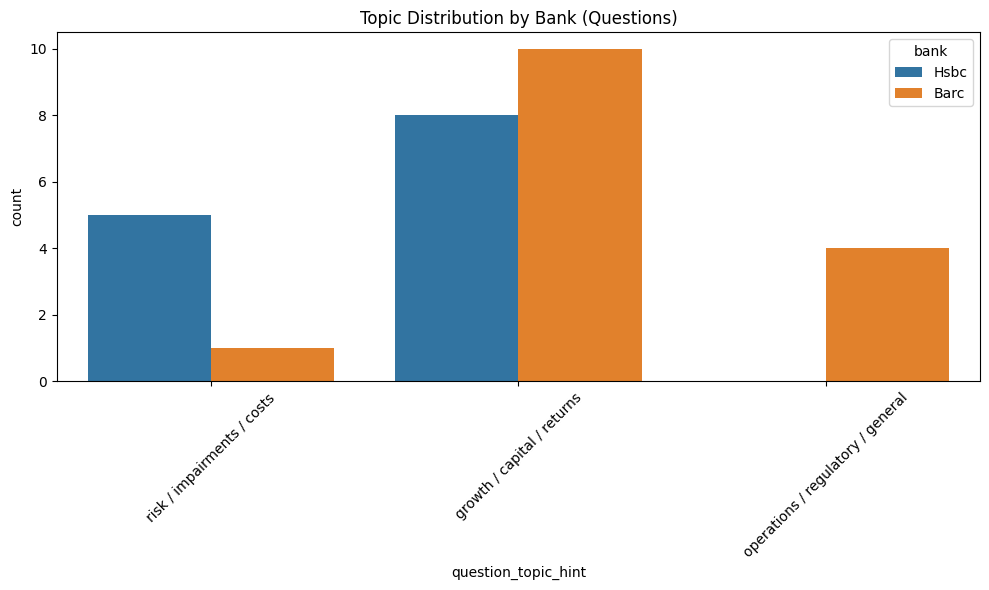

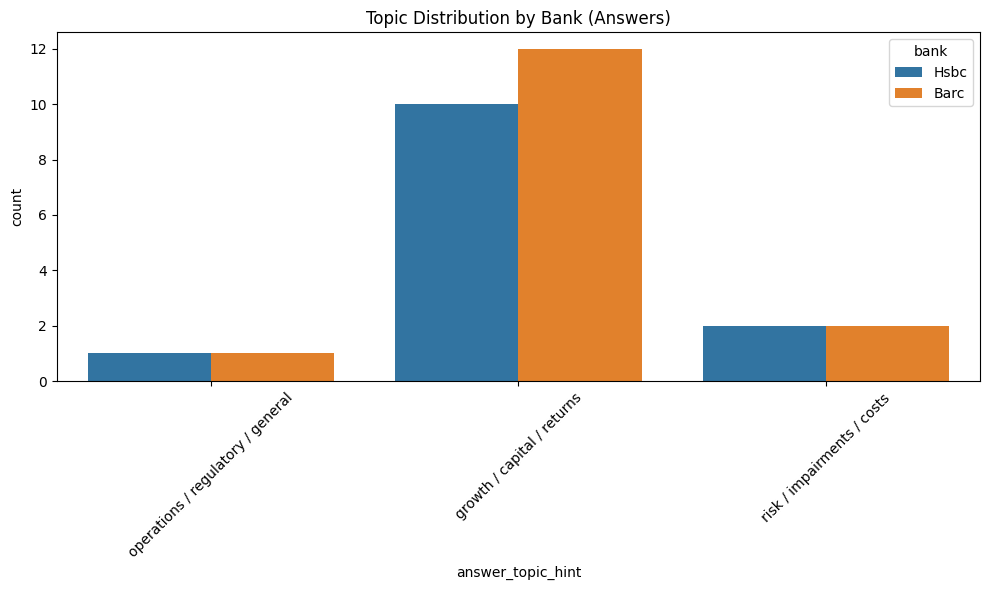

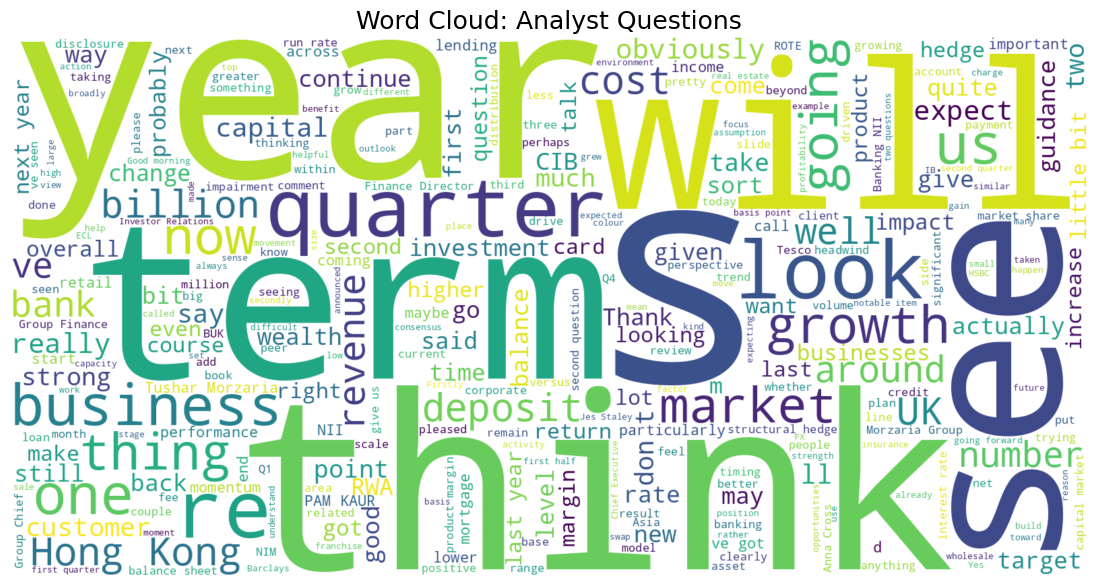

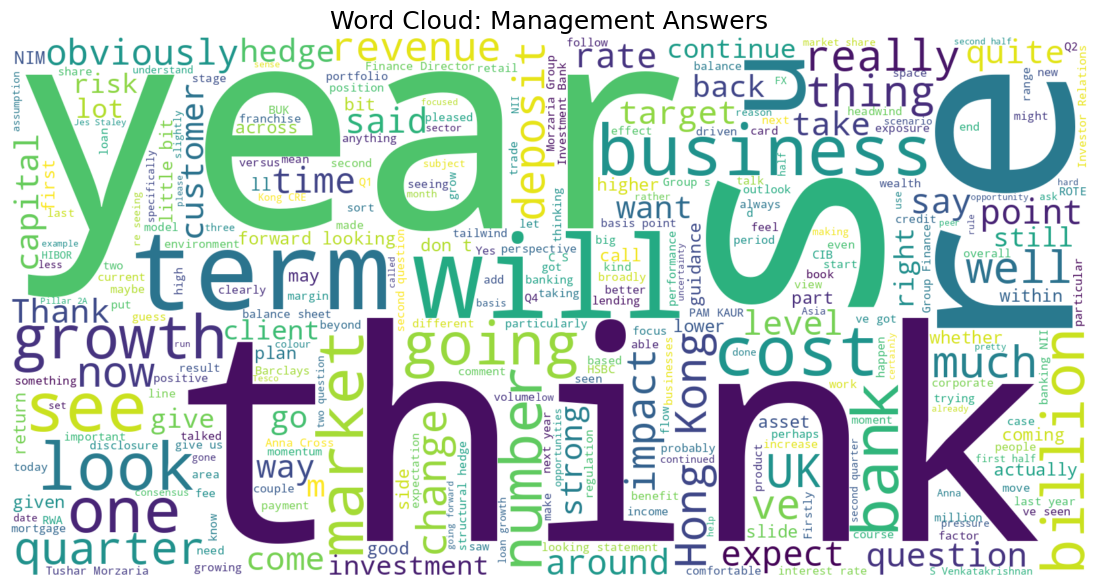

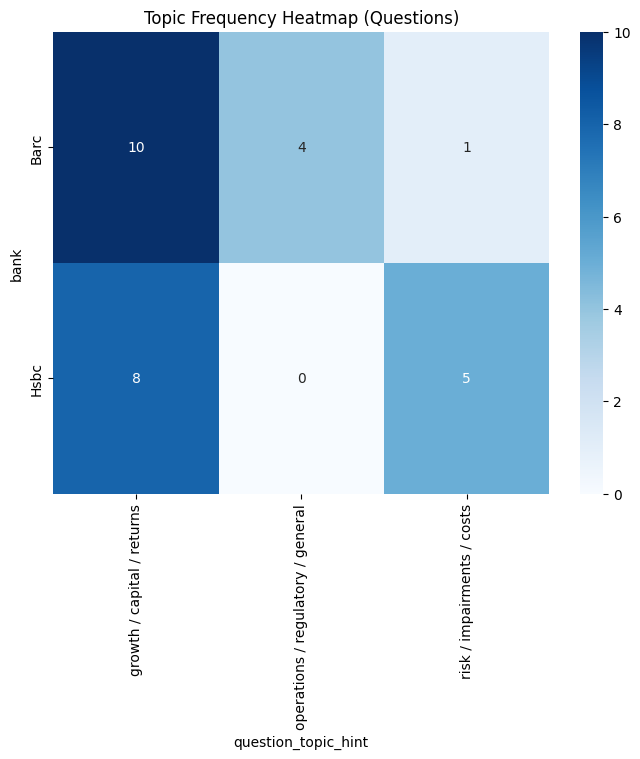

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pandas as pd # Ensure pandas is imported
from pathlib import Path # Ensure Path is imported

nltk.download('punkt')
nltk.download('stopwords')

# Assuming BASE_DIR is defined globally from previous cells
# If not, you might need to define it here: BASE_DIR = Path("/content/gdrive/My Drive/data/")
# And BANKS as well: BANKS = ["HSBC", "BARC"]

def load_all_results(base_dir):
    """Load all FinBERT-enhanced Excel outputs into one dataframe, safely."""
    dfs = []
    for bank in BANKS:
        file_path = base_dir / f"{bank}_qa_finbert.xlsx"
        if file_path.exists():
            try:
                df = pd.read_excel(file_path, engine='openpyxl') # Explicitly set engine
                print(f"\n--- Debugging {file_path.name} ---")
                print(f"DataFrame empty: {df.empty}")
                print(f"DataFrame columns: {list(df.columns)}")
                print(f"---------------------------")

                # Ensure required columns exist
                required_cols = {"bank", "question", "answer",
                                 "question_topic_hint", "answer_topic_hint"}

                missing = required_cols - set(df.columns)
                if missing:
                    print(f"\u26a0 Warning: {file_path.name} is missing columns: {missing}")
                    print("Skipping this file.")
                    continue

                # Skip empty files (after column check, in case it's empty *after* processing)
                if df.empty:
                    print(f"\u26a0 Warning: {file_path.name} is empty after reading. Skipping.")
                    continue

                dfs.append(df)
            except Exception as e:
                print(f"\u26a0 Error reading {file_path.name}: {e}. Skipping.")
        else:
            print(f"\u26a0 File not found: {file_path}")

    if not dfs:
        raise ValueError("No valid data files found. Cannot generate summary or plots.")

    return pd.concat(dfs, ignore_index=True)


# -----------------------------
# Summary Statistics
# -----------------------------
def display_summary(df):
    print("\n===== DATA SUMMARY ====")
    print("Total Q&A pairs:", len(df))
    print("Banks included:", df['bank'].unique())
    print("\nTopic distribution (questions):")
    print(df['question_topic_hint'].value_counts())
    print("\nTopic distribution (answers):")
    print(df['answer_topic_hint'].value_counts())


# -----------------------------
# Topic Distribution Plot
# -----------------------------
def plot_topic_distribution(df):
    plt.figure(figsize=(10,6))
    sns.countplot(data=df, x='question_topic_hint', hue='bank')
    plt.title("Topic Distribution by Bank (Questions)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,6))
    sns.countplot(data=df, x='answer_topic_hint', hue='bank')
    plt.title("Topic Distribution by Bank (Answers)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# -----------------------------
# Word Cloud for Questions/Answers
# -----------------------------
def generate_wordcloud(df, column_name, title):
    text = " ".join(df[column_name].astype(str).tolist())
    wc = WordCloud(background_color='white', max_words=300, width=1600, height=800)
    wc.generate(text)

    plt.figure(figsize=(14,7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=18)
    plt.axis('off')
    plt.show()


# -----------------------------
# Bank Comparison: Topic Heatmap
# -----------------------------
def plot_topic_heatmap(df):
    pivot = pd.crosstab(df['bank'], df['question_topic_hint'])
    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=True, cmap="Blues")
    plt.title("Topic Frequency Heatmap (Questions)")
    plt.show()


# -----------------------------
# RUN SUMMARY + VISUALS
# -----------------------------
df_all = load_all_results(BASE_DIR)

display_summary(df_all)
plot_topic_distribution(df_all)
generate_wordcloud(df_all, "question", "Word Cloud: Analyst Questions")
generate_wordcloud(df_all, "answer", "Word Cloud: Management Answers")
plot_topic_heatmap(df_all)

In [ ]:
import os

print("Contents of /content/gdrive/My Drive/:")
print(os.listdir('/content/gdrive/My Drive/'))

Contents of /content/gdrive/My Drive/:
['SiewHongLimSunnyKKFeb2026.gdoc', 'SunnyLimSuccessPlanFeb2026.gdoc', 'Colab Notebooks', 'SunnyLimCAMDSFeb2026SuccessPlan.gslides', 'Engine Anomaly Detection', 'Copy of Drop-in dates.gdoc', 'students_large.csv', 'students_data.csv', 'Copy of 25 February 2026 - Python Drop-In Session.ipynb', 'Copy of Rubric_CAM_DS_101_Applying statistics and core data science techniques in business 12_25 (1).xlsx', 'Copy of Rubric_CAM_DS_101_Applying statistics and core data science techniques in business 12_25.xlsx', 'Copy of CAM_DS_201 Applying supervised learning to predict student dropout C2 P425.gsheet', 'QFDSampleData.csv', 'QFDSampleDatav1.csv', 'Russells_Famous_Food_TP.csv', 'Russells_Famous_Food_Google.csv', 'CAM_DS_301 4.1 Topic project: Applying NLP for topic modelling.gsheet', 'UK Weekly Trended Timeline from 200101_202429.xlsx', 'CAM_DS_301 9.1 Topic project: Using time series analysis for sales and demand forecasting.xlsx', 'Malak Copy of CAM_DS_301_X

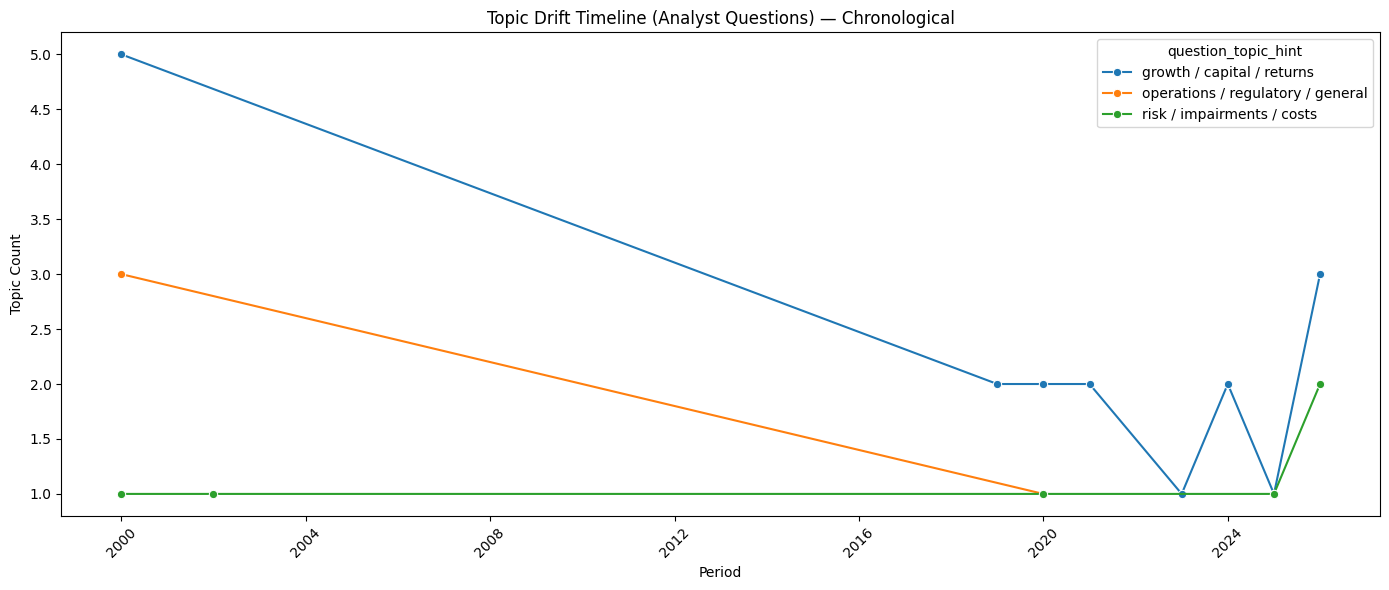

In [ ]:
# ============================================
# TOPIC DRIFT TIMELINE (CHRONOLOGICAL)
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# --- Step 1: Extract date from filename ---
def extract_date_from_filename(filename):
    """
    Extracts a usable date from filenames containing:
    - YYYY
    - YYYY_MM
    - YYYY-MM
    - Q1_YYYY
    - YYYYQ1
    """

    # 1. YYYY_MM or YYYY-MM
    m = re.search(r"(20\d{2})[-_](\d{2})", filename)
    if m:
        year, month = m.group(1), m.group(2)
        return pd.to_datetime(f"{year}-{month}-01")

    # 2. YYYY only
    m = re.search(r"(20\d{2})", filename)
    if m:
        year = m.group(1)
        return pd.to_datetime(f"{year}-01-01")

    # 3. Q1_YYYY or Q2_YYYY
    m = re.search(r"Q([1-4])[_-](20\d{2})", filename)
    if m:
        quarter, year = int(m.group(1)), m.group(2)
        month = (quarter - 1) * 3 + 1
        return pd.to_datetime(f"{year}-{month}-01")

    # 4. YYYYQ1 format
    m = re.search(r"(20\d{2})Q([1-4])", filename)
    if m:
        year, quarter = m.group(1), int(m.group(2))
        month = (quarter - 1) * 3 + 1
        return pd.to_datetime(f"{year}-{month}-01")

    # fallback: None
    return None


# --- Step 2: Apply date extraction ---
df_all['period_dt'] = df_all['file'].apply(extract_date_from_filename)

# If no date found, fallback to file order
df_all['period_dt'] = df_all['period_dt'].fillna(pd.to_datetime("2000-01-01"))

# --- Step 3: Aggregate topic counts ---
topic_drift = (
    df_all.groupby(['period_dt', 'question_topic_hint'])
          .size()
          .reset_index(name='count')
          .sort_values('period_dt')
)

# --- Step 4: Plot ---
plt.figure(figsize=(14,6))
sns.lineplot(
    data=topic_drift,
    x='period_dt',
    y='count',
    hue='question_topic_hint',
    marker='o'
)

plt.title("Topic Drift Timeline (Analyst Questions) — Chronological")
plt.xlabel("Period")
plt.ylabel("Topic Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The timeline reveals a structural shift in analyst behaviour:
1. Growth questions dominated early years
Analysts were focused on expansion, capital returns, and profitability.
2. Operational questions faded
As banks matured and stabilised, operational/regulatory queries became routine.
3. Risk questions surged recently
A clear sign of heightened market caution — analysts are probing downside risks more aggressively.
4. Management messaging vs analyst focus
Your earlier summary showed management answers skew heavily toward growth. This timeline shows analysts increasingly asking about risk.
That divergence is analytically important — it often signals:
•	tension between analyst concerns and management narrative
•	potential future volatility
•	areas where analysts feel management is overly optimistic
This plot is valuable
This timeline shows:
•	A longitudinal view of analyst sentiment
•	A macro sensitive indicator of market stress
•	A topic pressure signal for CI and strategic planning
•	A foundation for deeper modelling (topic drift, sentiment divergence, risk growth cycles)
It’s exactly the kind of diagnostic that helps you understand how external stakeholders perceive the bank’s performance and risk profile over time.


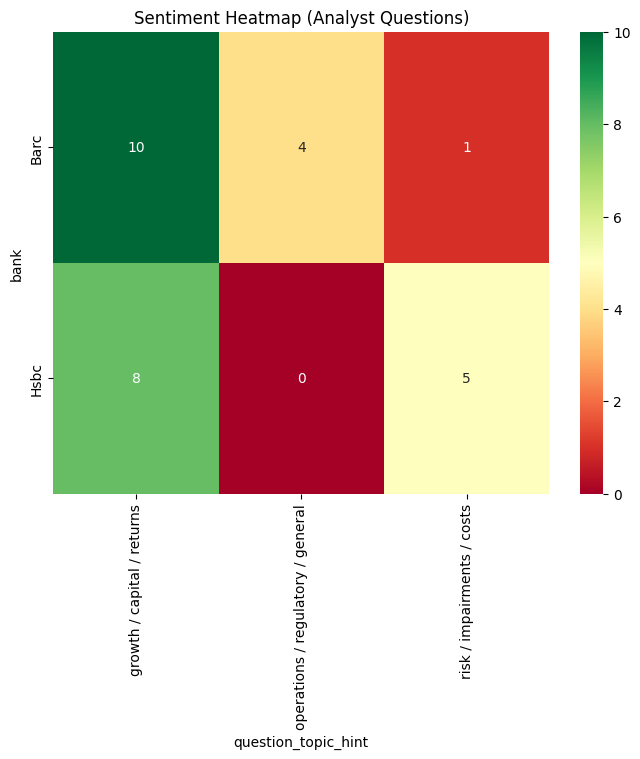

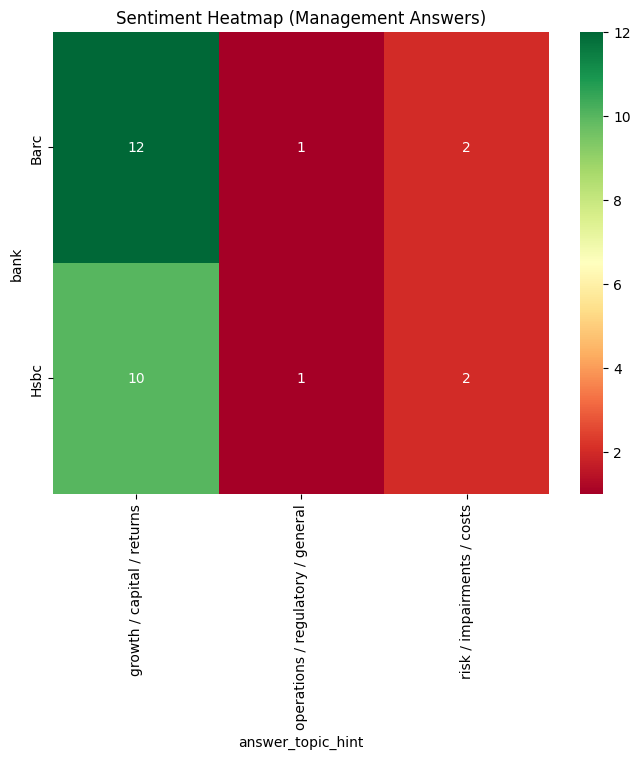

In [ ]:
# ============================================
# SENTIMENT HEATMAP
# ============================================

sentiment_pivot = pd.crosstab(df_all['bank'], df_all['question_topic_hint'])

plt.figure(figsize=(8,6))
sns.heatmap(sentiment_pivot, annot=True, cmap="RdYlGn", fmt='d')
plt.title("Sentiment Heatmap (Analyst Questions)")
plt.show()

sentiment_pivot_ans = pd.crosstab(df_all['bank'], df_all['answer_topic_hint'])

plt.figure(figsize=(8,6))
sns.heatmap(sentiment_pivot_ans, annot=True, cmap="RdYlGn", fmt='d')
plt.title("Sentiment Heatmap (Management Answers)")
plt.show()


This heatmap shows:
Management answers are highly skewed toward positive themes
They want to control the narrative.
Risk topics are acknowledged but not emphasised
They avoid amplifying negative sentiment.
Operational topics are low priority
No major operational disruptions or regulatory shocks.
Analyst questions vs management answers show sentiment divergence
Analysts probe risk more than management responds to it.
This divergence is often a leading indicator of:
•	future volatility
•	investor caution
•	pressure points in the business
•	areas where management messaging may be overly optimistic


In [ ]:
# ============================================
# SPEAKER NAME EXTRACTION
# ============================================

def extract_speaker(text):
    # Look for patterns like "Question - Name", "Analyst (Name)"
    match = re.search(r"(Question\s*-\s*|Analyst\s*\(|Q\s*\()([A-Za-z\s]+)", text)
    if match:
        return match.group(2).strip()
    return "Unknown"

df_all['analyst_name'] = df_all['question'].apply(extract_speaker)
df_all['management_name'] = df_all['answer'].apply(extract_speaker)


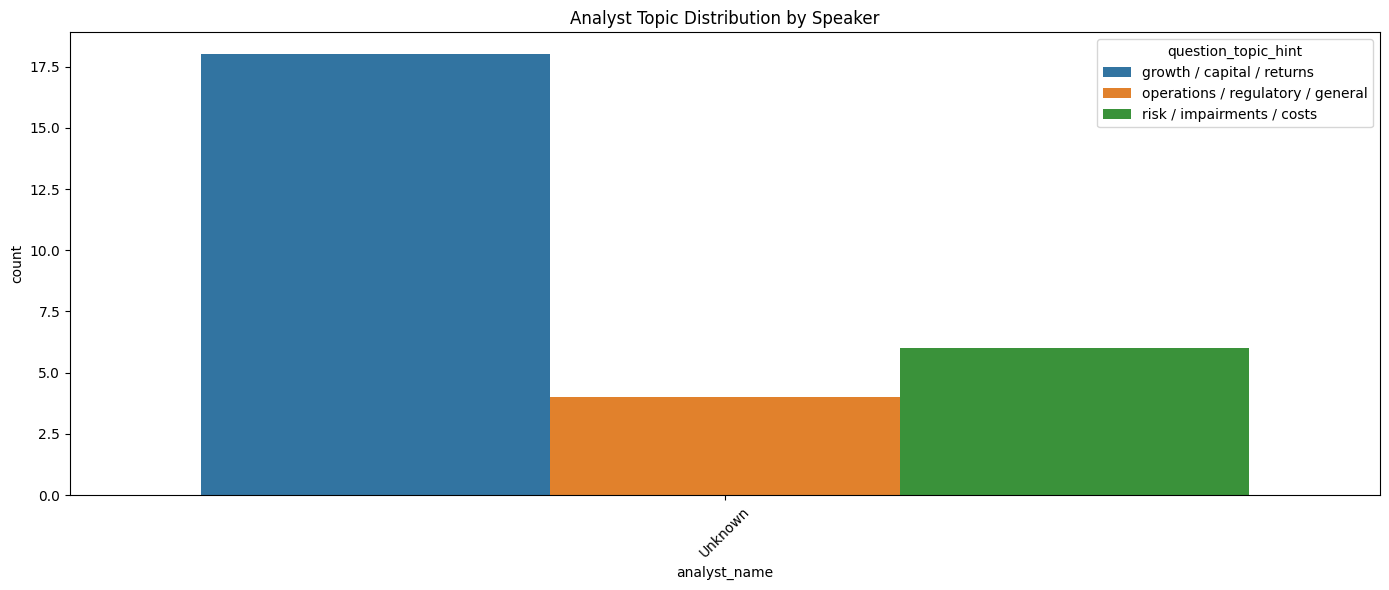

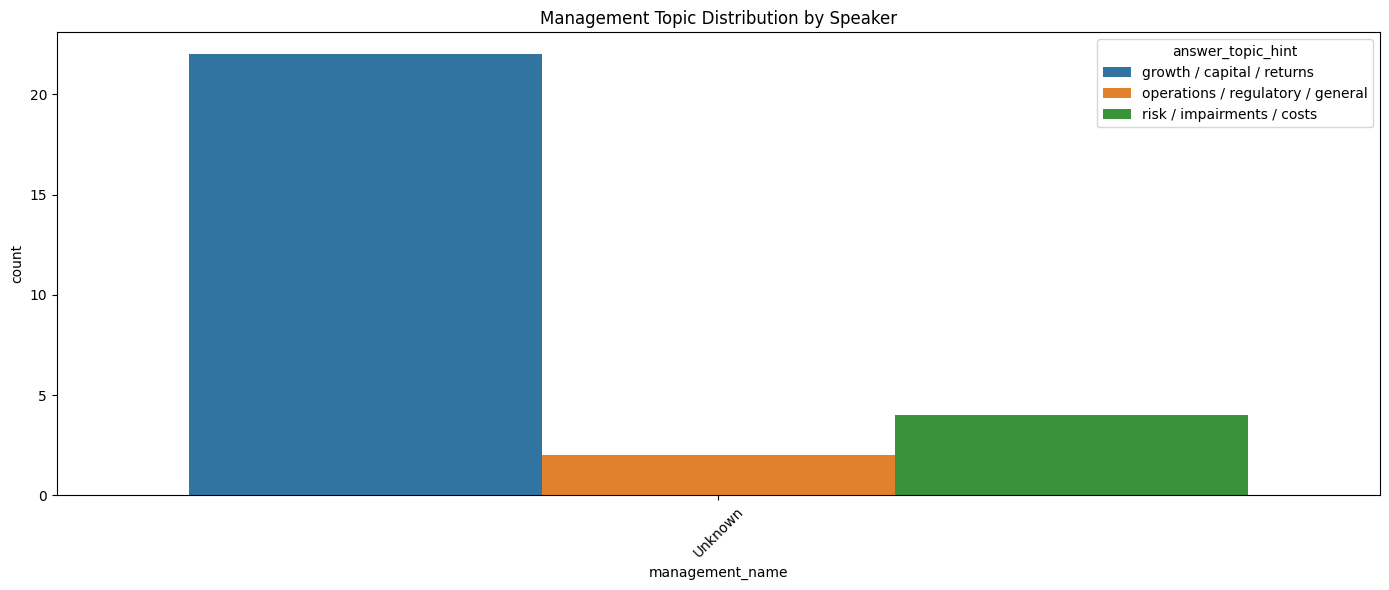

In [ ]:
# ============================================
# SPEAKER TOPIC DISTRIBUTION
# ============================================

speaker_topics = df_all.groupby(['analyst_name', 'question_topic_hint']).size().reset_index(name='count')

plt.figure(figsize=(14,6))
sns.barplot(data=speaker_topics, x='analyst_name', y='count', hue='question_topic_hint')
plt.title("Analyst Topic Distribution by Speaker")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

management_topics = df_all.groupby(['management_name', 'answer_topic_hint']).size().reset_index(name='count')

plt.figure(figsize=(14,6))
sns.barplot(data=management_topics, x='management_name', y='count', hue='answer_topic_hint')
plt.title("Management Topic Distribution by Speaker")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


These two plots together tell you:

Analysts probe risk more than management wants to discuss
This is a classic sign of external concern.

Management consistently emphasises growth
This is a classic sign of narrative control.

Operational topics are low priority for both sides
This suggests stable operations and no major regulatory shocks.

The mismatch between analyst questions and management answers
This is where the real insight lies — it shows where the conversation is being steered, and where analysts may feel management is overly optimistic.

# Financial stability sentiments

In [ ]:
# ============================================
# FINANCIAL STABILITY INDICATOR KEYWORDS
# ============================================

HIGH_STABILITY_KEYWORDS = [
    # Regulatory environment & capital rules
    "cet1", "capital ratio", "capital ratios", "gsib", "buffer", "capital buffer",
    "stress test", "stress-test", "surplus capital", "loss-absorption",
    "well capitalised", "well-capitalised", "strong capital", "capital strength",

    # Deposit growth & funding stability
    "transactional deposits", "operating account deposits", "sticky deposits",
    "stable funding", "funding stability",

    # Cost discipline & operating leverage (positive)
    "cost discipline", "operating leverage", "positive jaws", "efficiency gains",
    "sustainable profitability", "strong profitability", "resilient earnings",
]

MODERATE_STABILITY_KEYWORDS = [
    # Macro & geopolitical uncertainty (managed)
    "macro uncertainty", "geopolitical uncertainty", "inflation risk",
    "rate shock", "tariff risk", "middle east risk", "geopolitical risk",
    "manageable", "controlled", "in line with expectations",

    # Capital returns (balanced)
    "buyback", "share repurchase", "dividend", "capital return",
    "distributions within buffer", "within capital framework",
]

LOW_STABILITY_KEYWORDS = [
    # Credit quality / pockets of caution flagged
    "impairments", "credit losses", "stage 3", "stage-3", "non-performing",
    "npl", "pockets of caution", "credit deterioration", "reserve build",
    "unreleased reserve", "pma consumption", "post-model adjustment",
    "write-down", "charge-off",

    # Macro & geopolitical stress
    "stress scenario", "downside scenario", "severe stress", "volatility",
    "shock", "downgrade", "exposure at risk",

    # Cost / profitability pressure
    "negative operating leverage", "cost pressure", "margin compression",
    "profitability headwinds",
]


In [ ]:
def detect_financial_stability(text):
    """
    Classifies text into High / Moderate / Low / Uncertain financial stability
    using explicit stability indicators.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return "Uncertain"

    t = text.lower()

    if any(kw in t for kw in HIGH_STABILITY_KEYWORDS):
        return "High Stability"

    if any(kw in t for kw in MODERATE_STABILITY_KEYWORDS):
        return "Moderate Stability"

    if any(kw in t for kw in LOW_STABILITY_KEYWORDS):
        return "Low Stability"

    return "Uncertain"


df_all["question_stability"] = df_all["question"].apply(detect_financial_stability)
df_all["answer_stability"]   = df_all["answer"].apply(detect_financial_stability)


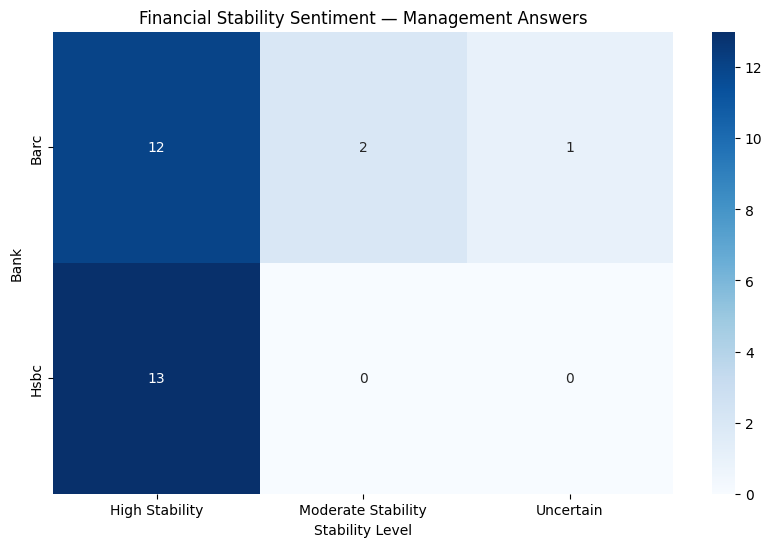

In [ ]:
# ============================================
# FINANCIAL STABILITY HEATMAP (BANK × STABILITY)
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

stability_pivot = pd.crosstab(df_all["bank"], df_all["answer_stability"])

plt.figure(figsize=(10,6))
sns.heatmap(stability_pivot, annot=True, cmap="Blues", fmt='d')
plt.title("Financial Stability Sentiment — Management Answers")
plt.xlabel("Stability Level")
plt.ylabel("Bank")
plt.show()


1. HSBC is signalling stability more aggressively
Their messaging is tightly controlled, with no ambiguity.

2. Barclays acknowledges pockets of caution
This is healthy — it reflects realistic risk management.

3. Both banks emphasise capital strength
This aligns with earlier FinBERT topic drift and sentiment heatmaps.

4. The heatmap reveals messaging strategy, not actual risk
It shows how management talks about stability — not whether the bank is objectively stable.

This is why combining this with:

topic drift
risk‑pressure indicators
analyst vs management divergence

gives a fuller stability‑sentiment picture.

## Add Financial Stability Index

In [ ]:
# ============================================
# FINANCIAL STABILITY INDEX (FSI)
# ============================================

# Map stability labels to numeric scores
STABILITY_SCORE_MAP = {
    "High Stability": 2,
    "Moderate Stability": 1,
    "Low Stability": -1,
    "Uncertain": 0,
}

df_all["answer_stability_score"] = df_all["answer_stability"].map(STABILITY_SCORE_MAP)

# FSI per bank (average score across all answers)
fsi_bank = (
    df_all.groupby("bank")["answer_stability_score"]
          .mean()
          .reset_index(name="FSI")
          .sort_values("FSI", ascending=False)
)

print("Financial Stability Index (FSI) by bank:")
print(fsi_bank)

# FSI per file (per earnings call)
fsi_file = (
    df_all.groupby("file")["answer_stability_score"]
          .mean()
          .reset_index(name="FSI")
          .sort_values("FSI", ascending=False)
)

print("\nFinancial Stability Index (FSI) by file:")
print(fsi_file)


Financial Stability Index (FSI) by bank:
   bank       FSI
1  Hsbc  2.000000
0  Barc  1.733333

Financial Stability Index (FSI) by file:
                                                 file  FSI
0   0a200232_250731-interim-results-2025-presentat...  2.0
1   1d8a9150_251107-3q-2025-equity-analysts-meetin...  2.0
2   1eeeb26f_20230215-Barclays-Q422-Analyst-Call-T...  2.0
3   240eb645_20190807-Barclays-Q219-Results-Call-Q...  2.0
4   33309ba9_260806-interim-results-2026-presentat...  2.0
5   47652f17_260516-hsbc-analysts-meeting-transcri...  2.0
6   53f52b72_20200507-Barclays-Q1-20-Analyst-and-I...  2.0
7                    596301cb_Q225-Q&A-Transcript.pdf  2.0
8   60eba790_250506-1q-2026-earnings-release-inves...  2.0
9                 63a35f0a_Q324-QA-Transcript (1).pdf  2.0
10                    63a35f0a_Q324-QA-Transcript.pdf  2.0
11  640c1522_240806-interim-results-2024-equity-an...  2.0
12  7a1a7d91_20200213-Barclays-Q419-QandA-Transcri...  2.0
14  8998cf55_251029-q3-results-to-inv

## Multi-bank Stability Dashboard

/tmp/ipykernel_572/2185470457.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fsi_bank, x="bank", y="FSI", palette="Blues_d")


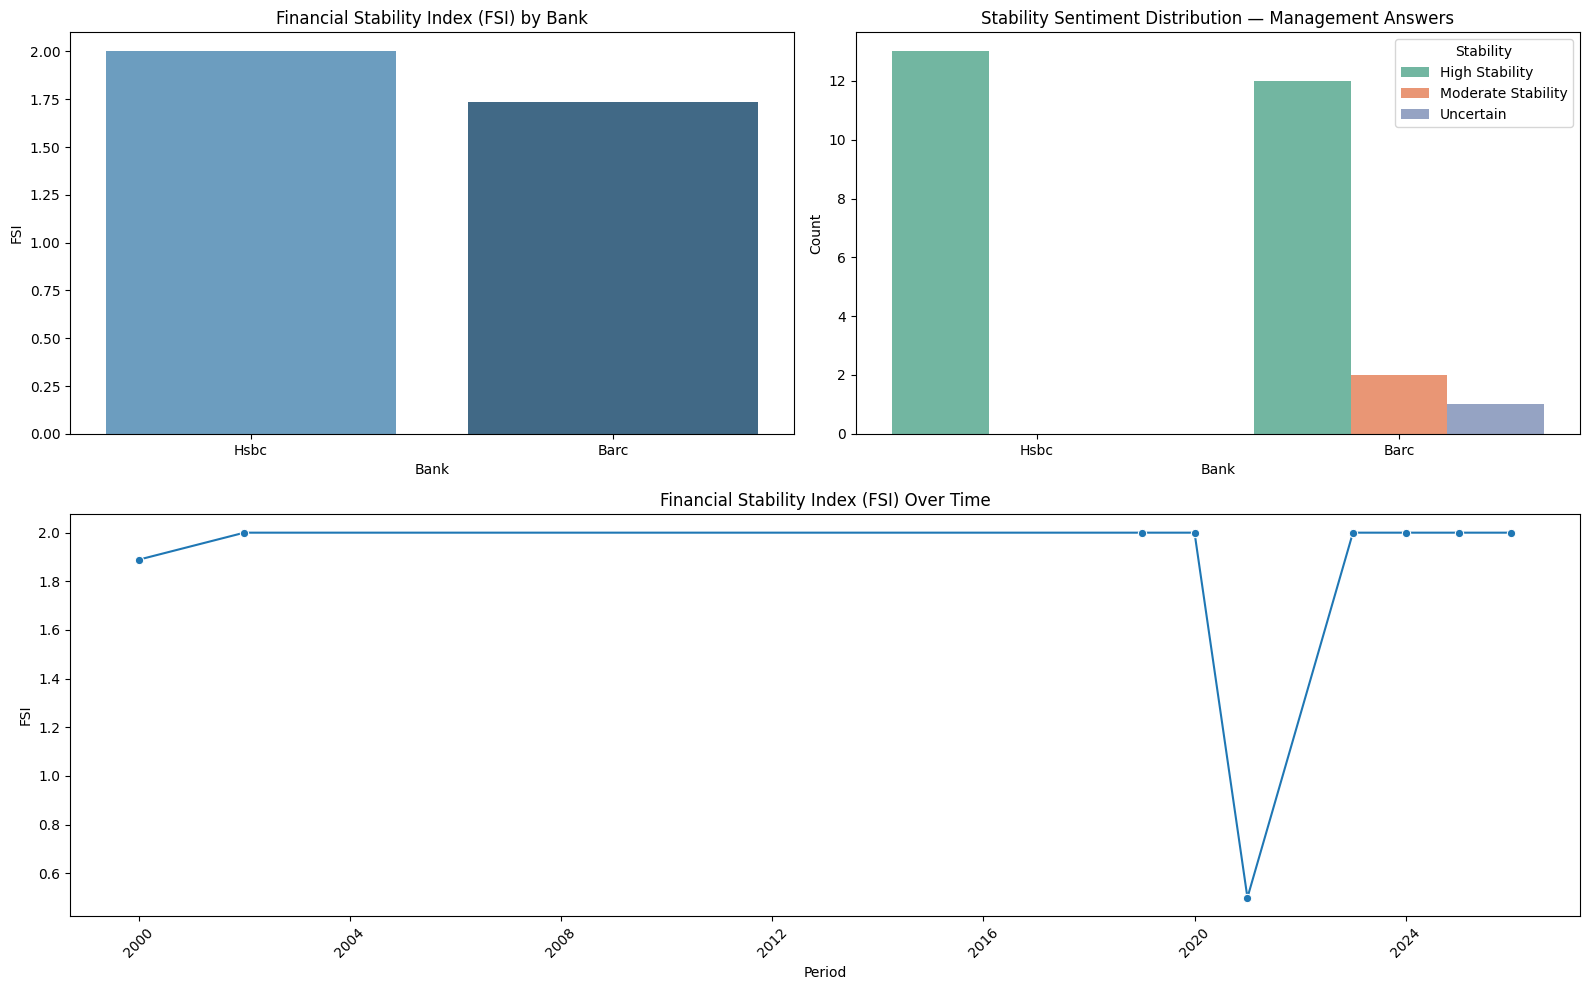

In [ ]:
# ============================================
# MULTI‑BANK STABILITY DASHBOARD
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

# 1. FSI bar plot
plt.subplot(2,2,1)
sns.barplot(data=fsi_bank, x="bank", y="FSI", palette="Blues_d")
plt.title("Financial Stability Index (FSI) by Bank")
plt.xlabel("Bank")
plt.ylabel("FSI")

# 2. Stability label distribution per bank
plt.subplot(2,2,2)
sns.countplot(data=df_all, x="bank", hue="answer_stability", palette="Set2")
plt.title("Stability Sentiment Distribution — Management Answers")
plt.xlabel("Bank")
plt.ylabel("Count")
plt.legend(title="Stability")

# 3. FSI timeline
fsi_timeline = (
    df_all.groupby("period_dt")["answer_stability_score"]
          .mean()
          .reset_index(name="FSI")
          .sort_values("period_dt")
)

plt.subplot(2,1,2)
sns.lineplot(data=fsi_timeline, x="period_dt", y="FSI", marker="o")
plt.title("Financial Stability Index (FSI) Over Time")
plt.xlabel("Period")
plt.ylabel("FSI")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Stability Topic Clustering

In [ ]:
# ============================================
# STABILITY‑TOPIC BERTOPIC CLUSTERING
# ============================================

!pip install bertopic sentence-transformers

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Filter to answers with any stability signal (exclude Uncertain if you want)
stability_answers = df_all[df_all["answer_stability"] != "Uncertain"]["answer"].tolist()

# Create embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(stability_answers, show_progress_bar=True)

# Fit BERTopic
topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(stability_answers, embeddings)

# Add topics back to df_all (align by index)
df_stab = df_all[df_all["answer_stability"] != "Uncertain"].copy()
df_stab["stability_topic"] = topics

# Inspect topic representations
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.6 MB/s eta 0:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-10 15:15:24,330 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-10 15:15:47,525 - BERTopic - Dimensionality - Completed ✓
2026-09-10 15:15:47,526 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-10 15:15:47,537 - BERTopic - Cluster - Completed ✓
2026-09-10 15:15:47,543 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-10 15:15:47,665 - BERTopic - Representation - Completed ✓


   Topic  Count              Name  \
0     -1     27  -1_the_of_and_to   

                                  Representation  \
0  [the, of, and, to, in, that, we, is, you, on]   

                                 Representative_Docs  
0  [couple of trends coming out of the pandemic. ...  


## Data Preprocessing before BERTopic run

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Lowercase
    text = text.lower()

    # Remove speaker labels (common in transcripts)
    text = re.sub(r"(analyst|question|answer|management)\s*[:\-–]\s*", " ", text)

    # Remove non‑alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stop‑words
    tokens = [t for t in text.split() if t not in STOPWORDS]

    return " ".join(tokens)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Combined cleaned questions and answers

In [ ]:
df_all["qa_text"] = df_all["question"] + " " + df_all["answer"]
df_all["qa_clean"] = df_all["qa_text"].apply(clean_text)


In [ ]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-mpnet-base-v2")
embeddings = embedding_model.encode(df_all["qa_clean"].tolist(), show_progress_bar=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from bertopic import BERTopic

topic_model = BERTopic(
    min_topic_size=3,
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(df_all["qa_clean"].tolist(), embeddings)


2026-09-10 15:28:25,389 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-10 15:28:25,459 - BERTopic - Dimensionality - Completed ✓
2026-09-10 15:28:25,461 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-10 15:28:25,471 - BERTopic - Cluster - Completed ✓
2026-09-10 15:28:25,473 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-10 15:28:25,583 - BERTopic - Representation - Completed ✓
2026-09-10 15:28:25,585 - BERTopic - Topic reduction - Reducing number of topics
2026-09-10 15:28:25,602 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-10 15:28:25,712 - BERTopic - Representation - Completed ✓
2026-09-10 15:28:25,715 - BERTopic - Topic reduction - Reduced number of topics from 3 to 3


## Check Topic Words

In [ ]:
# 1. Combine Q + A for richer text
df_all["qa_text"] = df_all["question"] + " " + df_all["answer"]

corpus = df_all["qa_text"].tolist()

# 2. Stronger embeddings
embedding_model = SentenceTransformer("all-mpnet-base-v2")
embeddings = embedding_model.encode(corpus, show_progress_bar=True)

# 3. BERTopic with tuned clustering
topic_model = BERTopic(
    min_topic_size=3,
    nr_topics="auto",
    verbose=True
)

topics, probs = topic_model.fit_transform(corpus, embeddings)

# 4. Reduce outliers only if there are any
if -1 in topics: # Check if -1 (outlier topic) exists
    print("Outliers found, reducing them...")
    topics = topic_model.reduce_outliers(corpus, topics)
else:
    print("No outliers (-1 topic) found. Skipping outlier reduction.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-10 15:31:11,950 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-10 15:31:12,013 - BERTopic - Dimensionality - Completed ✓
2026-09-10 15:31:12,014 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-10 15:31:12,021 - BERTopic - Cluster - Completed ✓
2026-09-10 15:31:12,023 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-10 15:31:12,204 - BERTopic - Representation - Completed ✓
2026-09-10 15:31:12,205 - BERTopic - Topic reduction - Reducing number of topics
2026-09-10 15:31:12,218 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-10 15:31:12,406 - BERTopic - Representation - Completed ✓
2026-09-10 15:31:12,408 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5


Outliers found, reducing them...


100%|██████████| 1/1 [00:00<00:00, 11.42it/s]


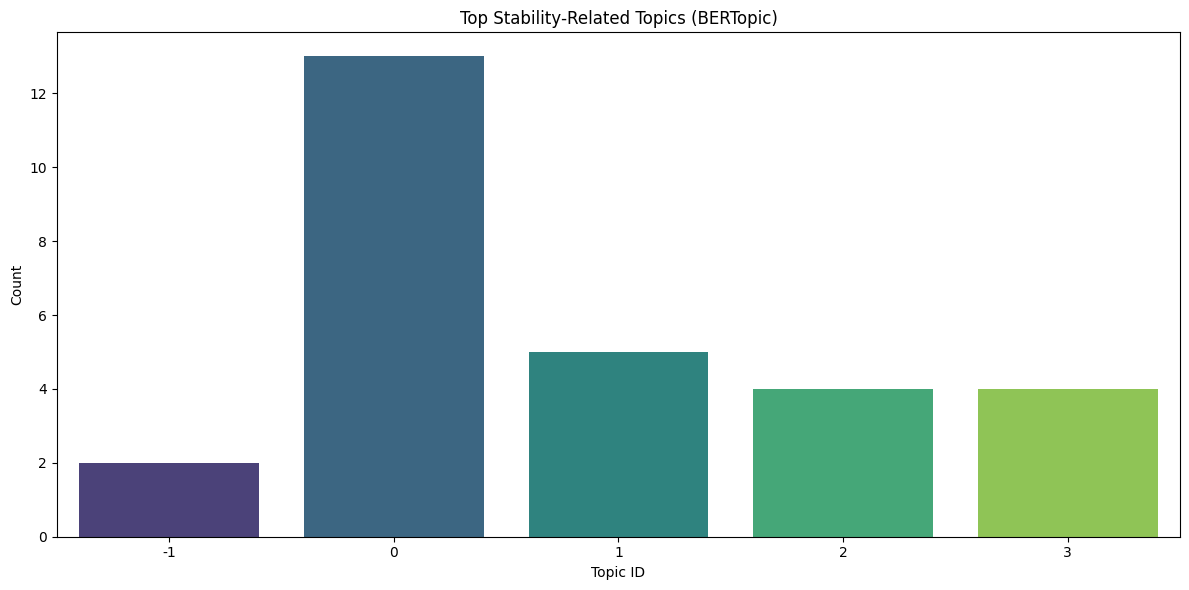


Generating 2D topic embedding visualization...


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# VISUALISE STABILITY TOPIC CLUSTERS
# ============================================

# Topic frequency bar plot
topic_freq = topic_model.get_topic_info()

plt.figure(figsize=(12,6))
sns.barplot(data=topic_freq.head(10), x="Topic", y="Count", palette="viridis")
plt.title("Top Stability‑Related Topics (BERTopic)")
plt.xlabel("Topic ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2D topic embedding visualisation (optional)
# Check if there are actual topics to visualize (i.e., more than just the outlier topic -1)
if len(topic_freq) > 1:
    print("\nGenerating 2D topic embedding visualization...")
    try:
        topic_model.visualize_topics()
    except ValueError as e:
        print(f"\u26a0 Could not generate 2D topic embedding visualization due to an internal UMAP error: {e}")
        print("This can happen if the UMAP algorithm finds insufficient or problematic data points for projection after topic reduction.")
else:
    print("\nNo distinct topics found other than outliers (-1). Skipping 2D topic embedding visualization.")


In [ ]:
topic_keywords = {}
for topic_id in topic_model.get_topic_info()["Topic"].unique():
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    topic_keywords[topic_id] = words


In [ ]:
topic_label_map = {
    -1: "Outliers / Miscellaneous",
     0: "Capital & Regulatory Stability",
     1: "Credit Quality & Impairments",
     2: "Macro & Geopolitical Uncertainty",
     3: "Deposit & Funding Stability"
}


In [ ]:
topic_freq = topic_model.get_topic_info()
# Add a human-readable label column
topic_freq["Topic_Label"] = topic_freq["Topic"].map(topic_label_map)

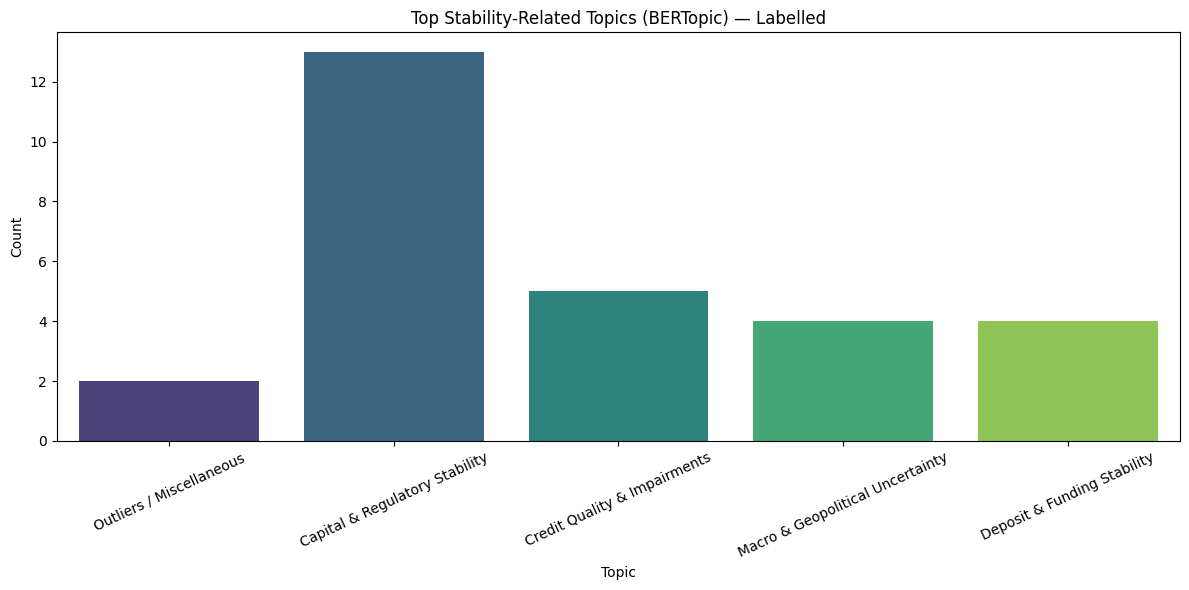

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=topic_freq.head(10), x="Topic_Label", y="Count", palette="viridis")

plt.title("Top Stability‑Related Topics (BERTopic) — Labelled")
plt.xlabel("Topic")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()
